# Foreground Maps Visualization

Generate and visualize key astrophysical foregrounds at 21cm frequencies: synchrotron emission, free-free emission, and point sources. These represent the dominant contamination sources that must be cleaned to detect dark photon signals.

## Setup

In [ ]:
import sys
import matplotlib_inline
sys.path.append("../")

import matplotlib.pyplot as plt
import matplotlib.pylab as pylab

# PySM3 for foreground modeling
import pysm3
import pysm3.units as u
import healpy as hp

import numpy as np
import pymaster as nmt  # For angular power spectrum analysis

matplotlib_inline.backend_inline.set_matplotlib_formats('retina')

%matplotlib inline
%load_ext autoreload
%autoreload 2

# Load custom plotting parameters
from plot_params import params
pylab.rcParams.update(params)

cols_default = plt.rcParams['axes.prop_cycle'].by_key()['color']

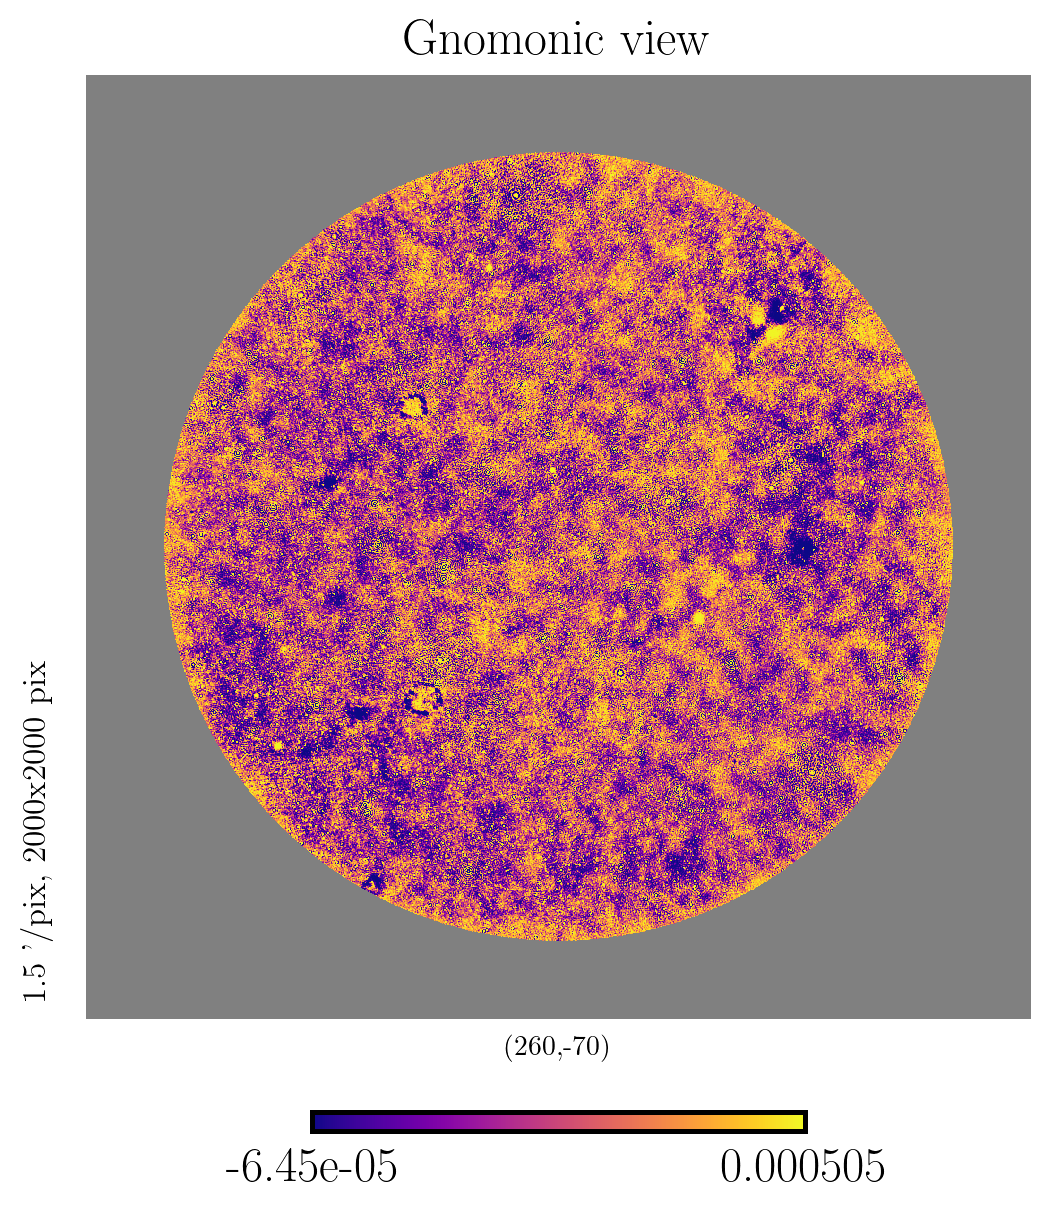

In [11]:
clean_map = hp.read_map("/projectnb/darkcosmo/dark_photon_project/21cmfast_cache/pyilc_pt_src_test/clean_needlet_ILC_map_roman_20deg_LOFARthermal_mK.fits")
mask = hp.read_map("/usr3/graduate/ebaker/dark_photon_constraints/ilc/pyilc_files/roman_mask_20deg.fits")
hp.gnomview(np.where(0==clean_map * mask, np.nan, clean_map), rot=(260, -70), xsize=2000, cmap="plasma", norm="hist")

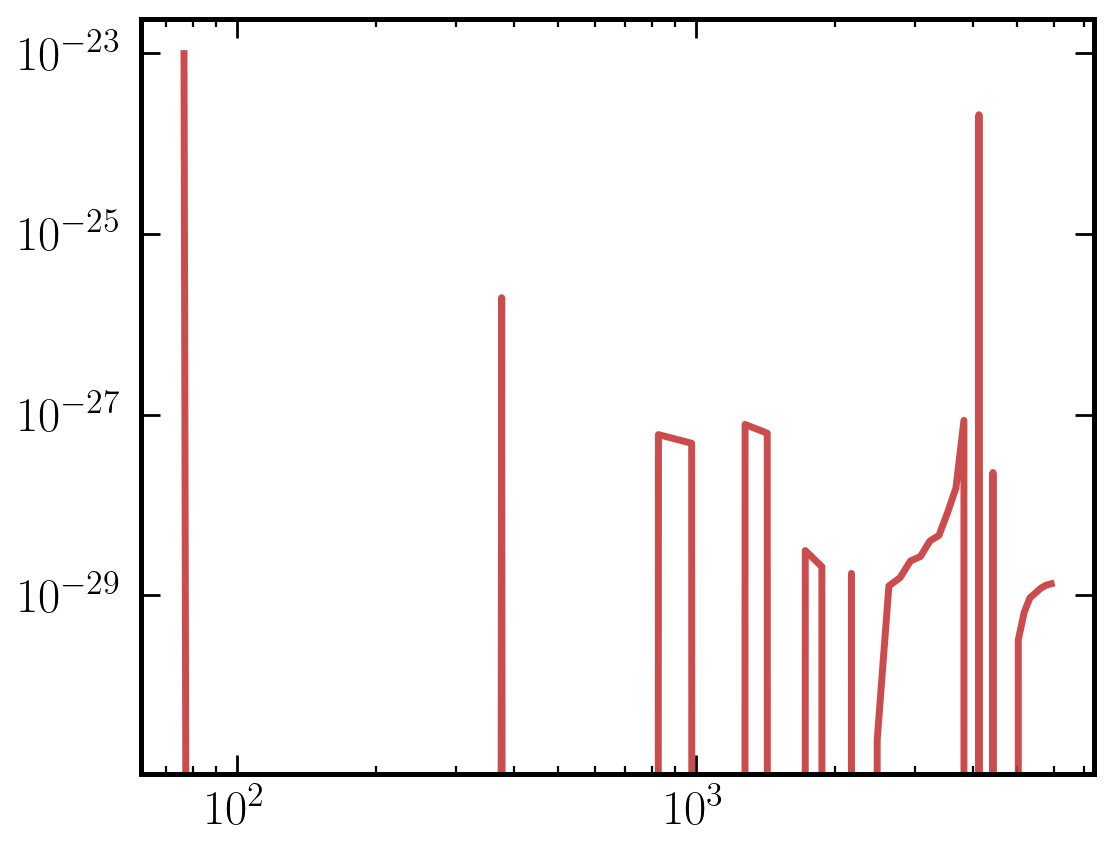

In [3]:
bels = nmt.NmtBin.from_nside_linear(2048, 150).get_effective_ells()
plt.loglog(bels, np.load("/projectnb/darkcosmo/dark_photon_project/21cmfast_cache/pyilc_pt_src_test/clean_auto_Cls_binning150.npy"))

## Generate Foreground Maps

Create maps of the three dominant foreground components at 410 MHz using PySM3 models.

In [9]:
nside = 2048  # HEALPix resolution
nu = 410. * u.MHz  # Frequency corresponding to 21cm at z~4.3

syncsky = pysm3.Sky(nside=nside, preset_strings=["s1"])
sync_map = syncsky.get_emission(nu)
sync_map = sync_map.to(u.mK_CMB, equivalencies=u.cmb_equivalencies(nu))
sync_Cls = hp.anafast(sync_map[0], lmax=4096)


In [2]:
pt_srcs = np.load("/projectnb/darkcosmo/dark_photon_project/21cmfast_cache/pyilc_alt_pt_src_100mJy_new_freq/Tb_nu_map2048.npy")[:,0]
pt_src_Cls = hp.anafast(pt_srcs, lmax=4096)

In [24]:
ls = np.arange(4097)
mock_Cls =  (ls)**(0.8-2) * pt_src_Cls[10] / (10)**(0.8-2)
mock_Cls[0] = 0
map = hp.synfast(mock_Cls, 2048, lmax=4096)

/scratch/ipykernel_122056/2659290984.py:2: RuntimeWarning: divide by zero encountered in power
  mock_Cls =  (ls)**(0.8-2) * pt_src_Cls[10] / (10)**(0.8-2)


In [7]:
from scipy.special import gamma as sci_gamma
gam=0.8
amp=7.8e-3 * (180/np.pi)**(-gam)
analytic_Cls = amp * np.pi * 2 ** (2-gam) * sci_gamma( 1- gam/2) / sci_gamma(gam/2) * (ls)**(gam - 2)

/scratch/ipykernel_408418/89874542.py:4: RuntimeWarning: divide by zero encountered in power
  analytic_Cls = amp * np.pi * 2 ** (2-gam) * sci_gamma( 1- gam/2) / sci_gamma(gam/2) * (ls)**(gam - 2)


In [4]:
pt_src_map = np.load("/projectnb/darkcosmo/dark_photon_project/21cmfast_cache/pyilc_pt_src_test/n_ps2048.npy")
pt_src_Cls = hp.anafast(pt_src_map, lmax=4096)

In [11]:
brightness_map = np.load("/projectnb/darkcosmo/dark_photon_project/21cmfast_cache/pyilc_foregrounds_0.1mJy/Tb_nu_map2048.npy")[:,0]
brightness_Cls = hp.anafast(brightness_map, lmax=4096)

In [15]:
map_490 = hp.read_map("/projectnb/darkcosmo/dark_photon_project/21cmfast_cache/pyilc_alt_pt_src_0.1mJy_new_freq/foregrounds_4.940.fits")
lofar_mask = hp.read_map("/usr3/graduate/ebaker/dark_photon_constraints/ilc/pyilc_files/subaru_mask_20deg.fits")

In [16]:
lofar_Cls = hp.anafast(map_490 * lofar_mask, lmax=4096) /np.mean(lofar_mask)**2

In [ ]:
np.mean_lofar

(1000.0, 10000.0)

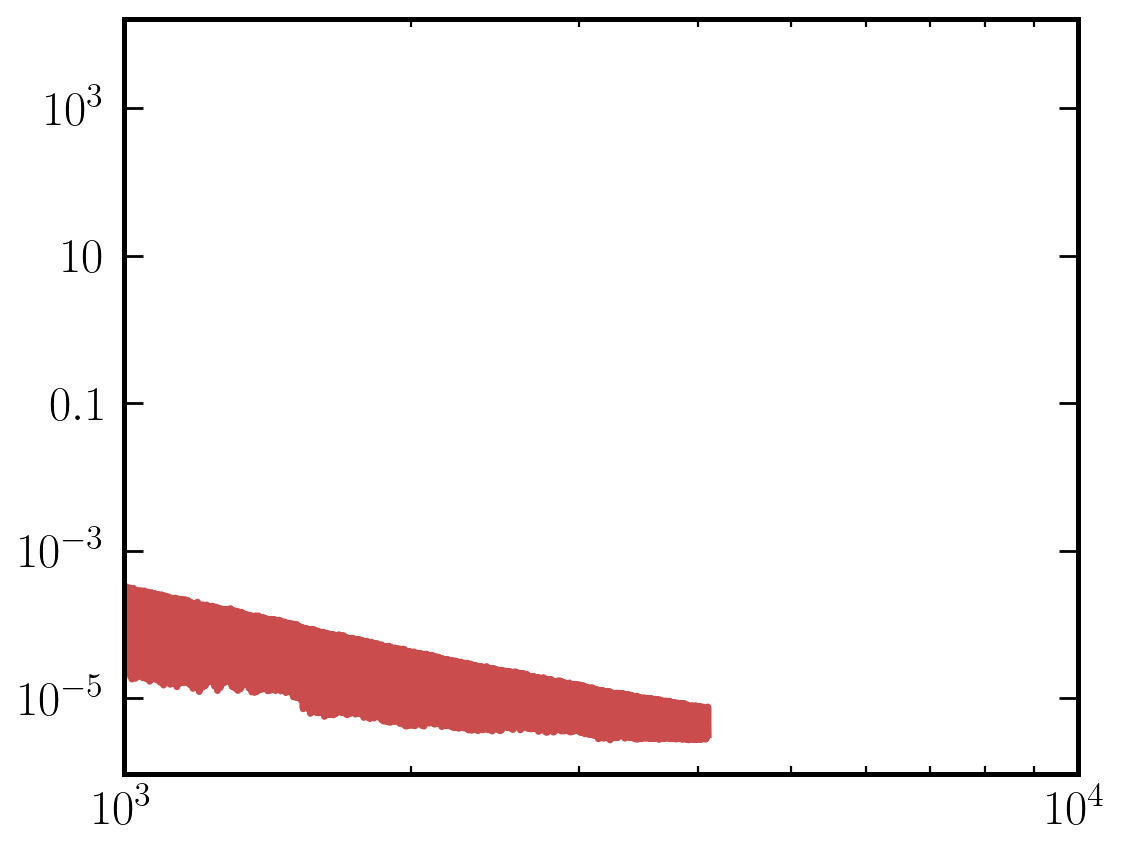

: 

In [ ]:
plt.loglog(ls, 1e6 * lofar_Cls)
plt.xlim(1e3, 1e4)

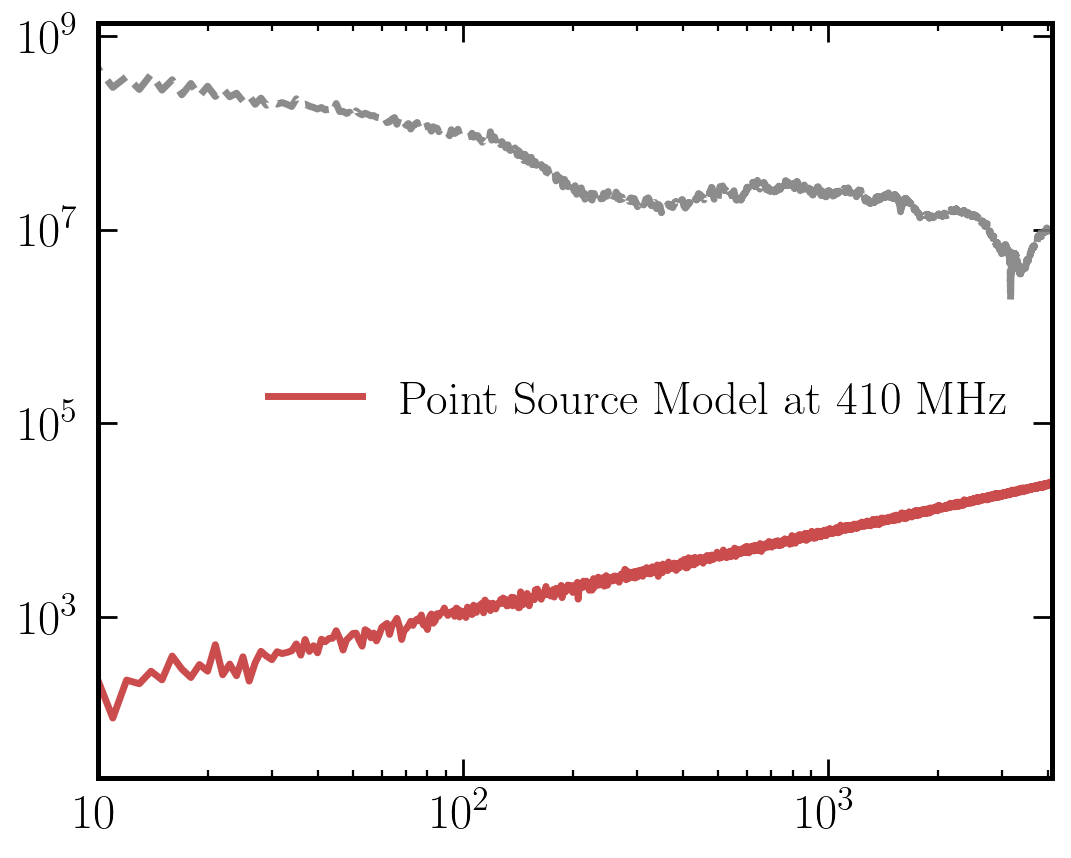

In [14]:
ls = np.arange(4097)
plt.loglog(ls,15e6 *  ls * (ls + 1) /2/np.pi * pt_src_Cls, label="Point Source Model at 410 MHz")
# plt.loglog(ls, old_pt_src_Cls, linestyle="--", color="gray")
plt.loglog(ls, ls * (ls + 1) /2/np.pi * sync_Cls, linestyle="--", color="gray")

plt.xlim(10, 4096)
# plt.ylim(1e-4,1e11)
plt.legend()

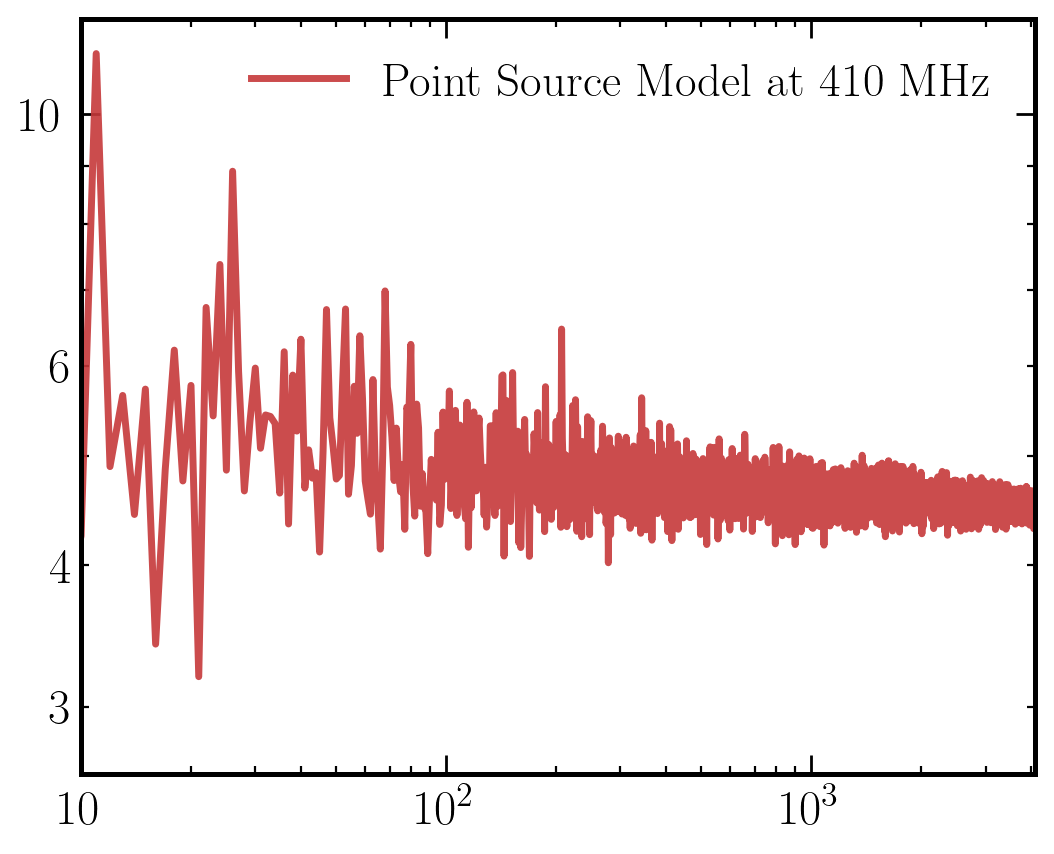

In [58]:
ls = np.arange(4097)
plt.loglog(ls, analytic_Cls/pt_src_Cls, label="Point Source Model at 410 MHz")
# plt.loglog(ls, , linestyle="--", color="gray")
plt.xlim(10, 4096)
# plt.ylim(1e-4,1e11)
plt.legend()

/scratch/ipykernel_122056/1730205127.py:4: RuntimeWarning: divide by zero encountered in power
  plt.loglog(ls, 1e6 * ls * (ls+1) * (ls)**(0.8-2) * pt_src_Cls[10] / (10)**(0.8-2), linestyle="--", color="gray")
/scratch/ipykernel_122056/1730205127.py:4: RuntimeWarning: invalid value encountered in multiply
  plt.loglog(ls, 1e6 * ls * (ls+1) * (ls)**(0.8-2) * pt_src_Cls[10] / (10)**(0.8-2), linestyle="--", color="gray")


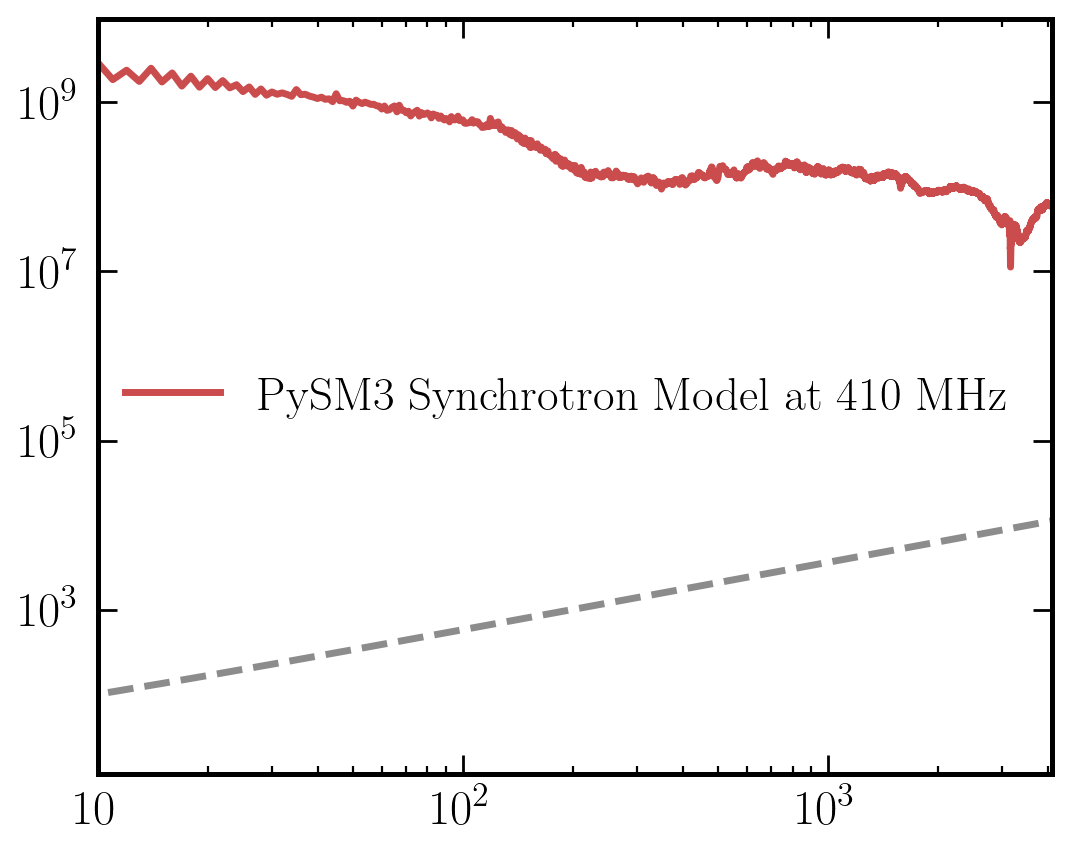

In [19]:
ls = np.arange(4097)
plt.loglog(ls, ls * (ls+1) * old_Cls, label="PySM3 Synchrotron Model at 410 MHz")
# plt.loglog(ls, pt_src_Cls, label="Point Source Model at 410 MHz")
plt.loglog(ls, 1e6 * ls * (ls+1) * (ls)**(0.8-2) * pt_src_Cls[10] / (10)**(0.8-2), linestyle="--", color="gray")
plt.xlim(10, 4096)
# plt.ylim(1e-4,1e11)
plt.legend()

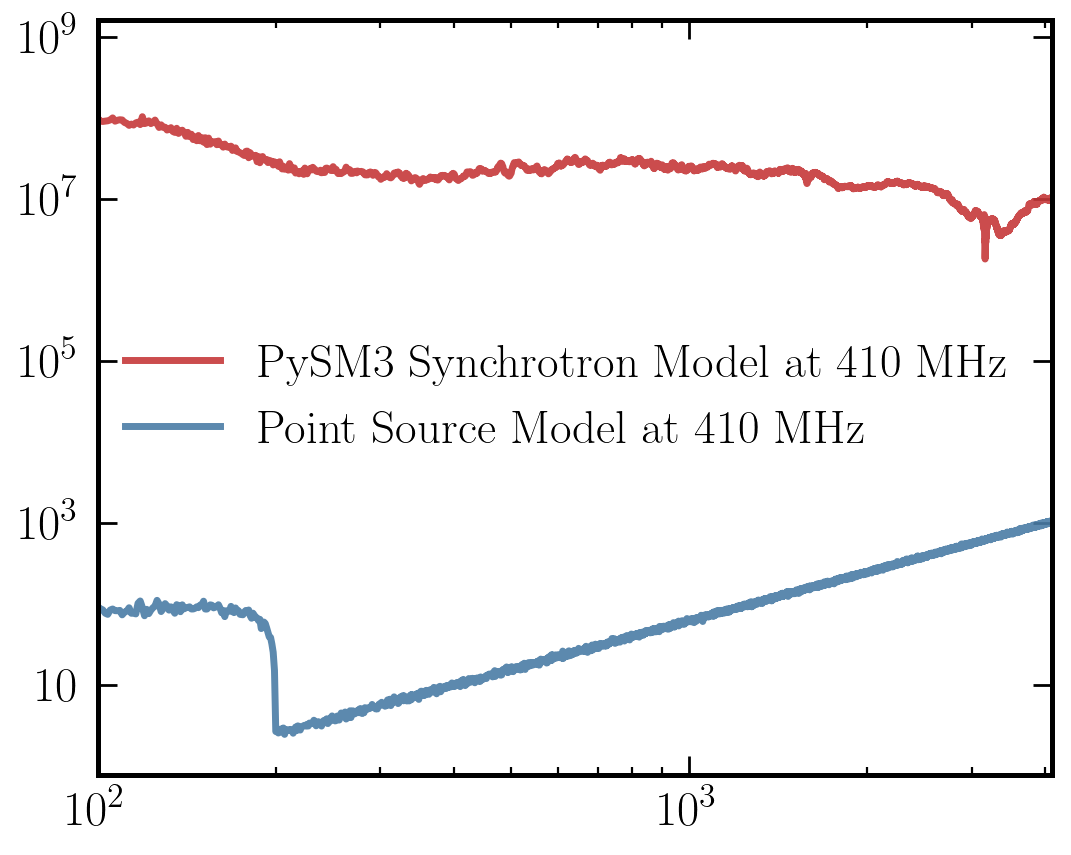

In [ ]:
ls = np.arange(4097)
plt.loglog(ls, ls * (ls + 1) * old_Cls / 2 / np.pi, label="PySM3 Synchrotron Model at 410 MHz")
# plt.loglog(ls, 1e6 * ls * (ls + 1) * pt_src_Cls / 2 / np.pi, label="Point Source Model at 410 MHz")
plt.xlim(100, 4096)
# plt.ylim(1e-4,1e11)
plt.legend()

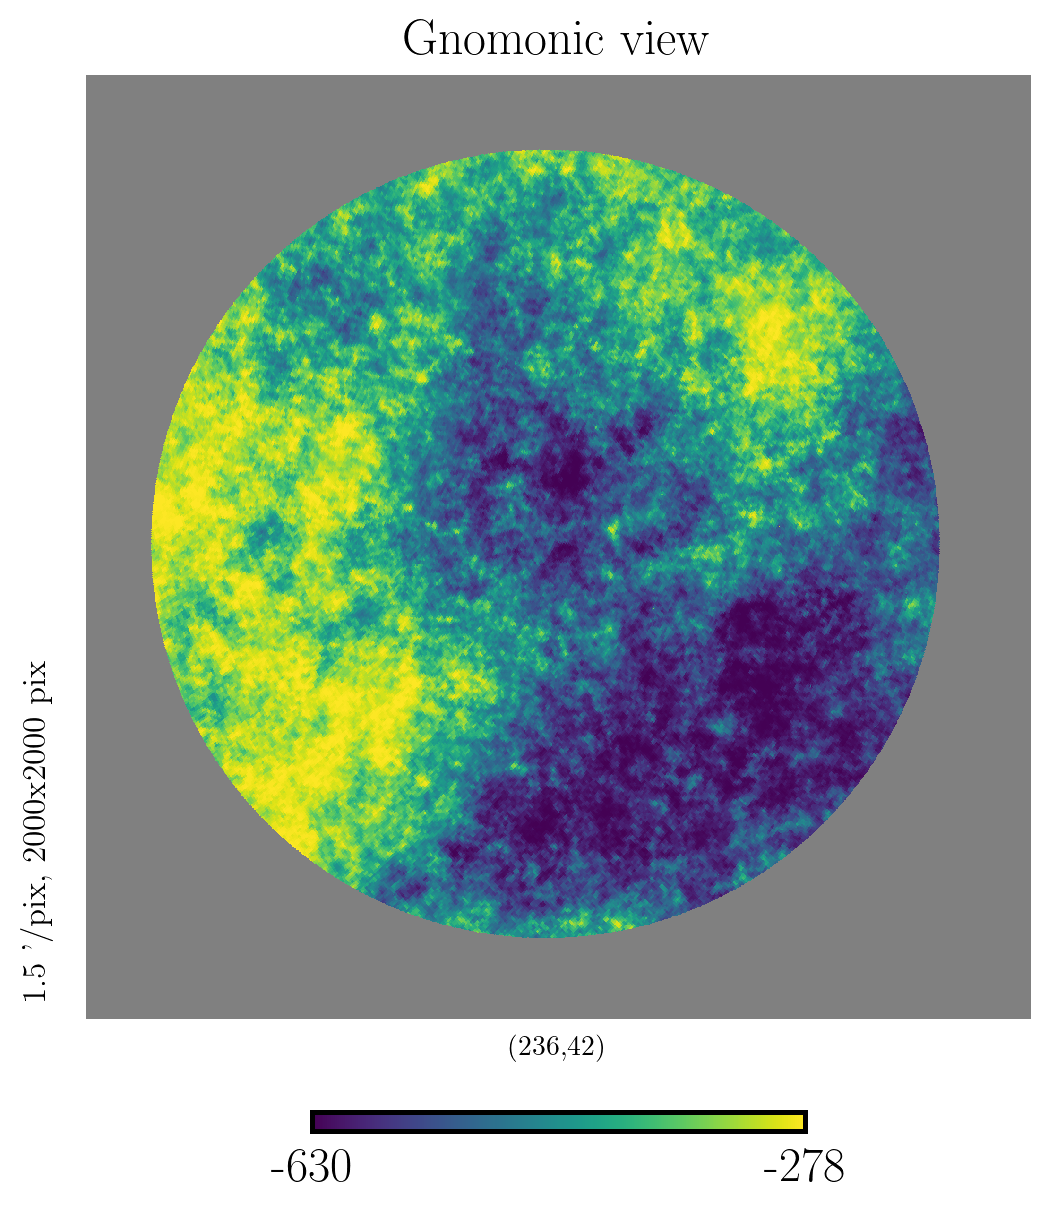

In [25]:
mask = hp.read_map("/usr3/graduate/ebaker/dark_photon_constraints/ilc/pyilc_files/subaru_mask_20deg.fits")
lofar_map = hp.read_map("/projectnb/darkcosmo/dark_photon_project/21cmfast_cache/pyilc_lofar/foregrounds_nu0.140_thermal.fits")
hp.gnomview(np.where(0==mask * lofar_map, np.nan, lofar_map), rot=(236, 42), xsize=2000, norm="hist")

In [34]:
fake_Cls = hp.anafast(np.where(0==mask * lofar_map, hp.UNSEEN, lofar_map), lmax=4096)

In [39]:
np.mean(mask**2)

0.03015365203221639

(0.01, 10000000.0)

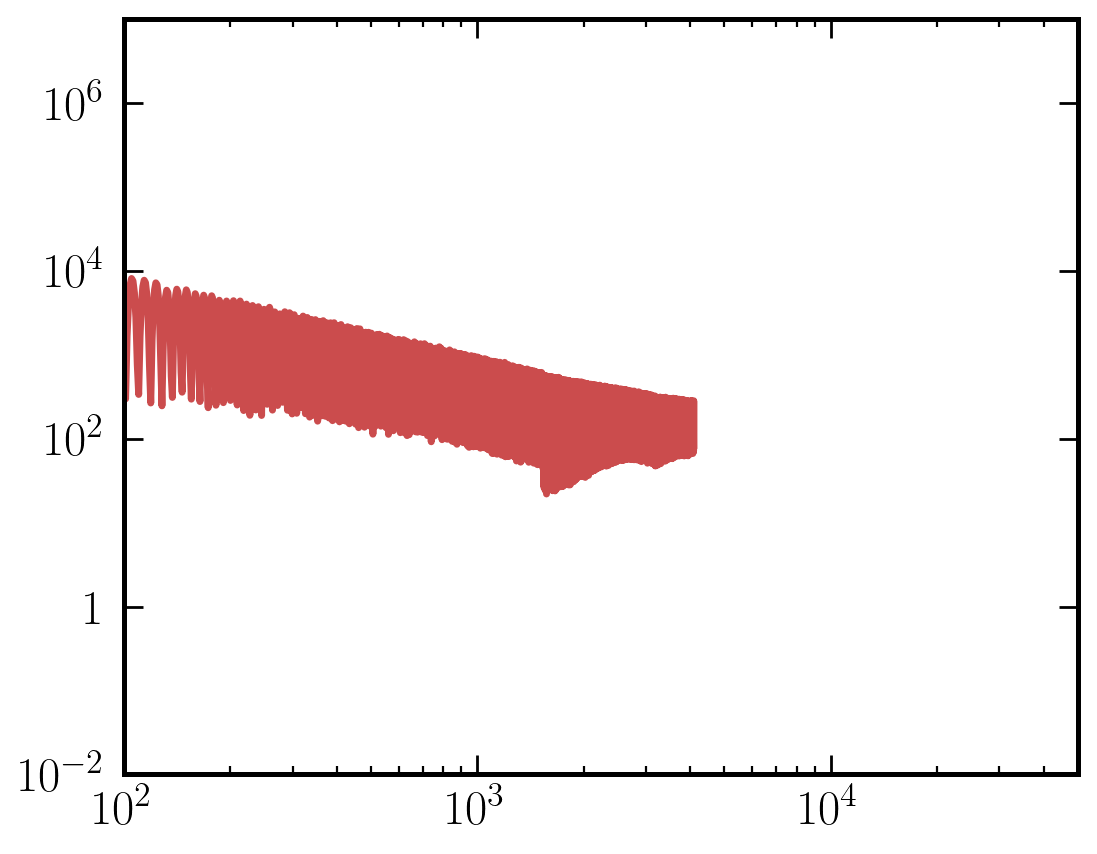

In [43]:
ls = np.arange(4097)
plt.loglog(ls, ls * (ls + 1) * fake_Cls / 2 / np.pi / np.mean(mask**2), label="PySM3 Synchrotron Model at 410 MHz")
plt.xlim(100, 5e4)
plt.ylim(1e-2, 1e7)

(0.01, 10000000.0)

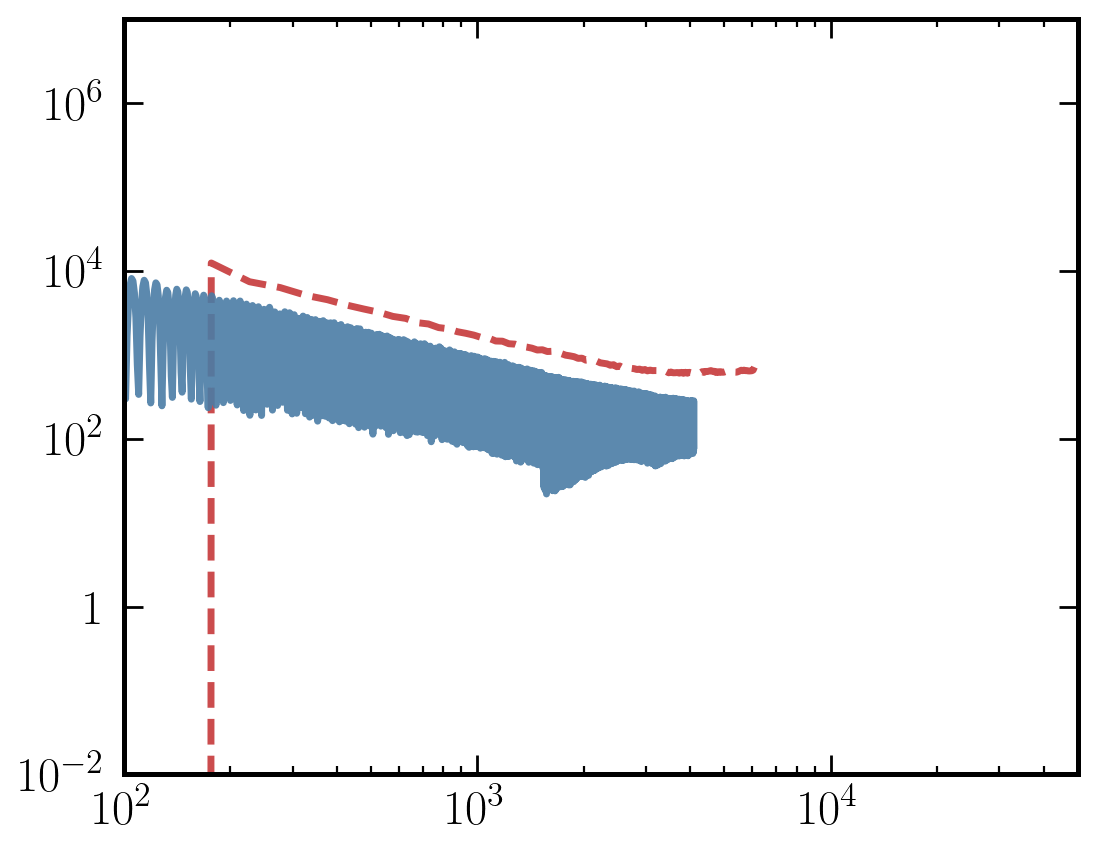

In [44]:
binning = nmt.NmtBin.from_nside_linear(2048, 50)
bls = binning.get_effective_ells()
lofar_Cls = np.load("/projectnb/darkcosmo/dark_photon_project/21cmfast_cache/pyilc_lofar/clean_auto_Cls_binning50.npy")
plt.loglog(bls, -bls * (bls + 1) * lofar_Cls/2/np.pi, "--")
plt.loglog(ls, ls * (ls + 1) * fake_Cls / 2 / np.pi / np.mean(mask**2), label="PySM3 Synchrotron Model at 410 MHz")

plt.xlim(100, 5e4)
plt.ylim(1e-2, 1e7)


In [3]:
old_Cls = hp.anafast(sync_map[0], lmax=4096)


In [ ]:
A = 0.0028e6
alpha = 2.2
beta = 2.55
zeta = 4.0
nu0 = 122
l0 = 180
nup = nu
ls = np.arange(4097)

mock_Cls = A * (ls /l0)**-alpha * (nu * nup / nu0**2)**-beta * np.exp(- 0.5 * zeta**2 * np.log(nu/nup)**2)

/scratch/ipykernel_1810606/3735791608.py:10: RuntimeWarning: divide by zero encountered in power
  mock_Cls = A * (ls /l0)**-alpha * (nu * nup / nu0**2)**-beta * np.exp(- 0.5 * zeta**2 * np.log(nu/nup)**2)


In [9]:
pt_src = np.load("/projectnb/darkcosmo/dark_photon_project/21cmfast_cache/pyilc_alt_pt_src_0.1mJy_new_freq/Tb_nu_map2048.npy")

In [11]:
pt_src.shape

(50331648, 9)

In [16]:
nside = 2048  # HEALPix resolution
nu = 140. * u.MHz  # Frequency corresponding to 21cm at z~4.3

syncsky = pysm3.Sky(nside=nside, preset_strings=["s1"])
sync_map = syncsky.get_emission(nu)
sync_map = sync_map.to(u.mK_CMB, equivalencies=u.cmb_equivalencies(nu))
old_Cls = hp.anafast(sync_map[0], lmax=4096)


In [ ]:
pt_src_Cl = hp.anafast(pt_src[:,0], lmax=4096)

In [25]:
lofar = hp.read_map("/projectnb/darkcosmo/dark_photon_project/21cmfast_cache/pyilc_lofar/foregrounds_nu0.140_thermal.fits")
lofar_Cl = hp.anafast(lofar, lmax=4096)
ls = np.arange(4097)


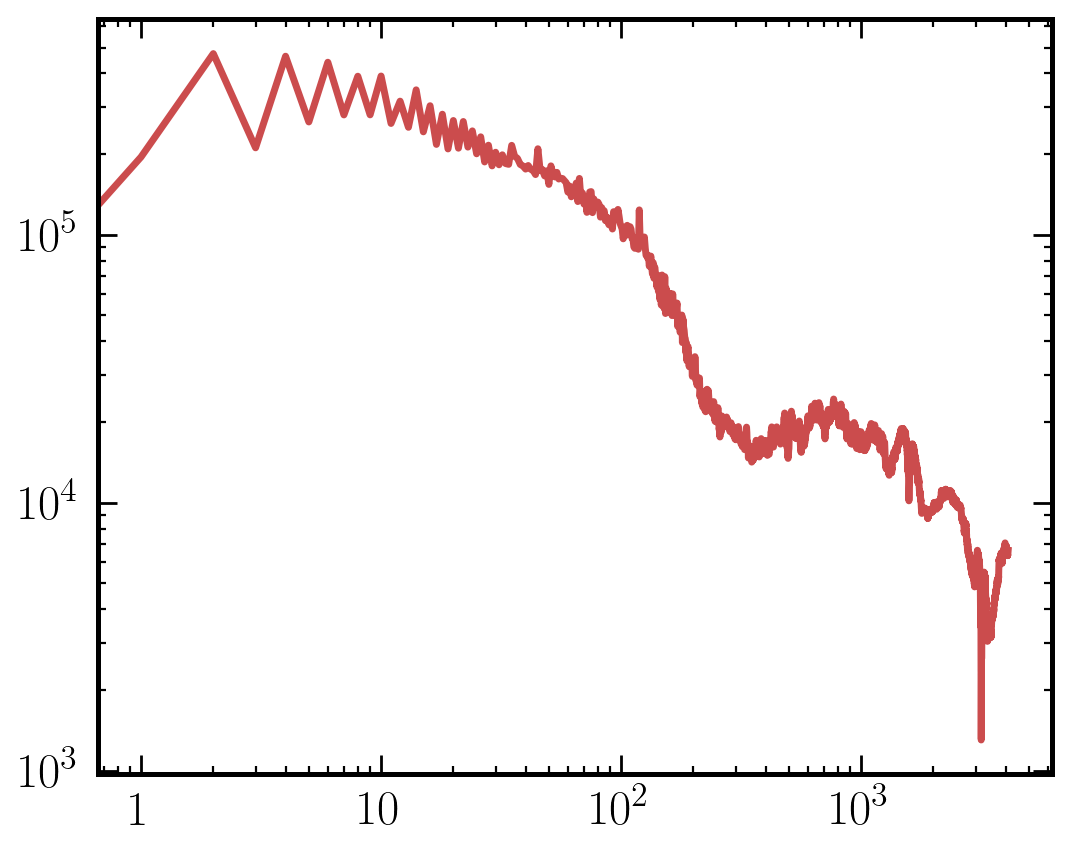

In [27]:
plt.loglog(ls, ls * (ls + 1) * lofar_Cl/2/np.pi, label='LOFAR FG model at 140 MHz')

(10, 10000.0)

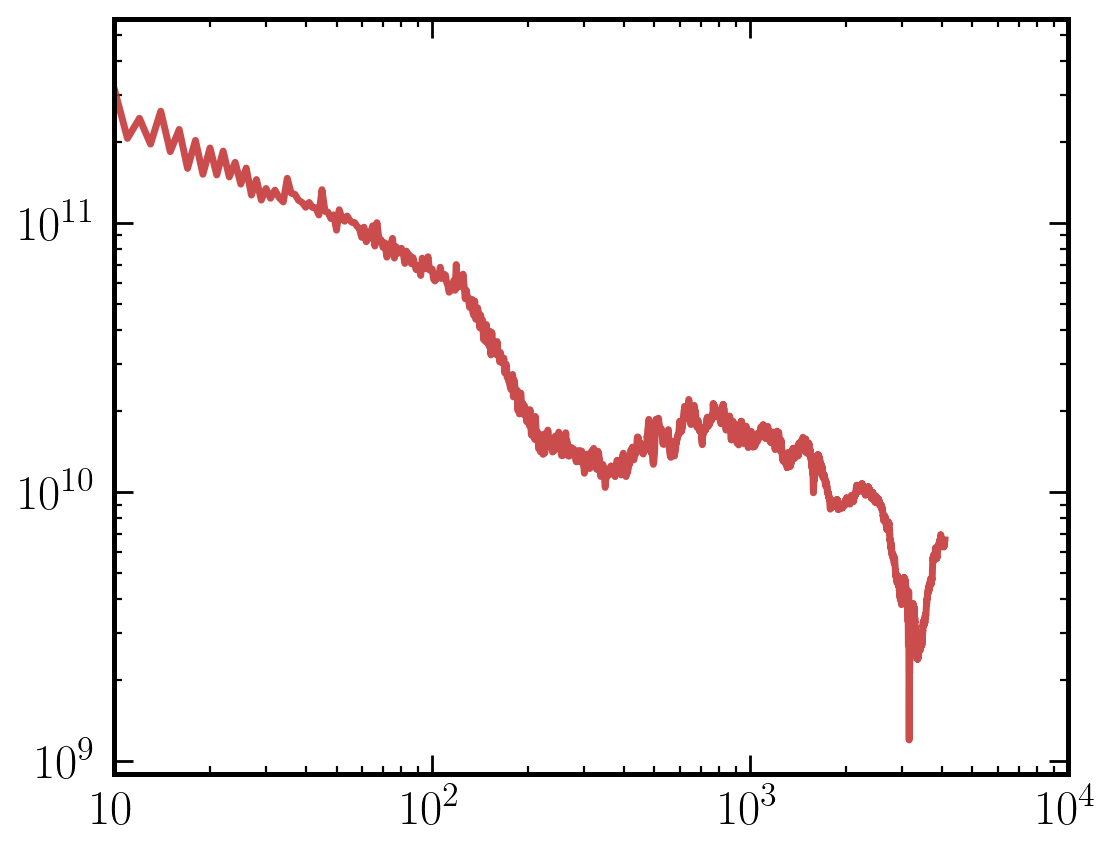

In [18]:
ls = np.arange(4097)
plt.loglog(ls, ls * (ls + 1) * old_Cls/2/np.pi)
# plt.loglog(ls, ls * (ls + 1) * 1e6 * pt_src_Cl/2/np.pi)
plt.xlim(10, 1e4)
# plt.ylim(1e-4, 1e10)

In [ ]:
nside = 2048  # HEALPix resolution
nu = 410. * u.MHz 

new_sync_sky = pysm3.Sky(nside=nside, preset_strings=["s5"])
new_sync_map = new_sync_sky.get_emission(nu)
new_sync_map = new_sync_map.to(u.mK_CMB, equivalencies=u.cmb_equivalencies(nu))

In [ ]:
new_Cls = hp.anafast(new_sync_map, lmax=4096)
old_Cls = hp.anafast(sync_map, lmax=4096)

In [ ]:
pysm

pysm3.sky.Sky

: 

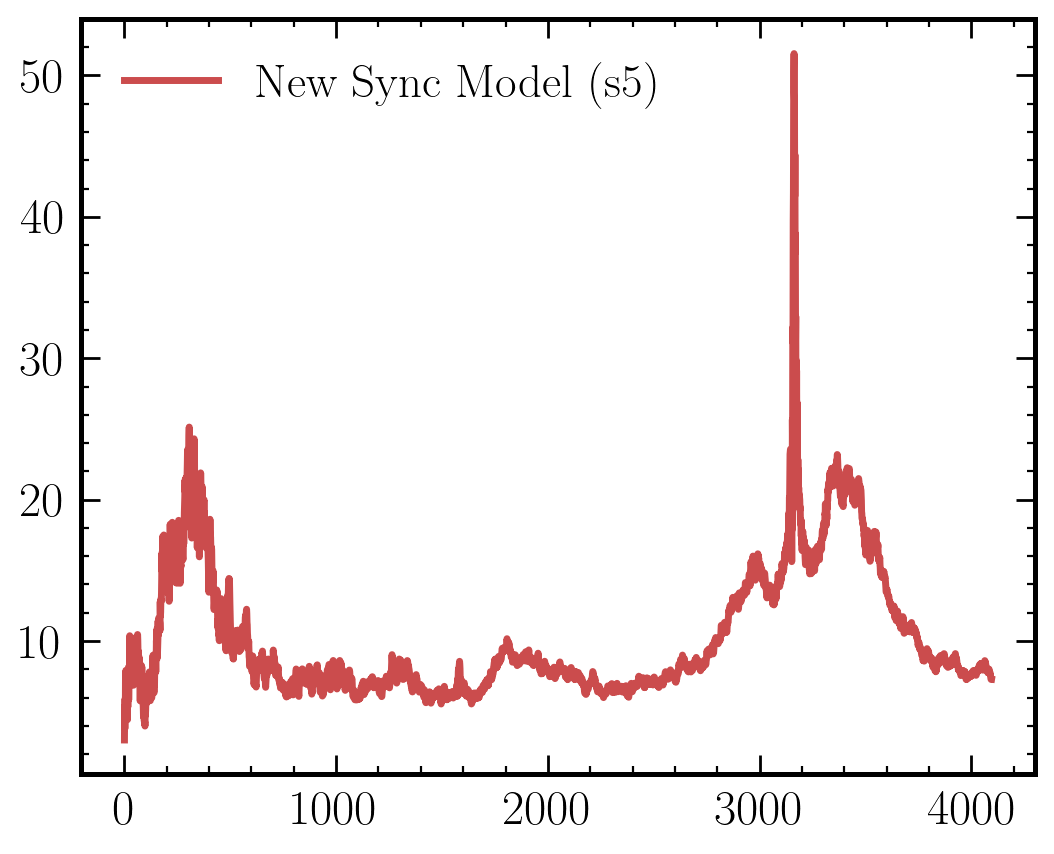

In [17]:
plt.plot(ls, new_Cls[0]/old_Cls[0], label='New Sync Model (s5)')
# plt.loglog(ls, , label='Old Sync Model (s1)')
plt.legend()

In [3]:
mask = hp.read_map("/usr3/graduate/ebaker/dark_photon_constraints/ilc/pyilc_files/roman_mask_20deg.fits")

In [ ]:
nside = 2048  # HEALPix resolution
nu = 1430. * u.MHz  # Frequency corresponding to 21cm at z~4.3

# Free-free emission (thermal bremsstrahlung from ionized gas)
freefreesky = pysm3.Sky(nside=nside, preset_strings=["f1"])
freefree_map = freefreesky.get_emission(nu)
freefree_map = freefree_map.to(u.mK_CMB, equivalencies=u.cmb_equivalencies(nu))

# Synchrotron emission (relativistic electrons in magnetic fields)
syncsky = pysm3.Sky(nside=nside, preset_strings=["s1"])
sync_map = syncsky.get_emission(nu)
sync_map = sync_map.to(u.mK_CMB, equivalencies=u.cmb_equivalencies(nu))

amesky = pysm3.Sky(nside=nside, preset_strings=["a1"])
ame_maps = amesky.get_emission(nu)
ame_maps = ame_maps.to(u.mK_CMB, equivalencies=u.cmb_equivalencies(nu))

# Point sources (radio galaxies, quasars, etc.)
pt_srcs = 1000 * np.load("/projectnb/darkcosmo/dark_photon_project/21cmfast_cache/pyilc_alt_pt_src_0.1mJy_new_freq/Tb_nu_map2048.npy")[...,0]

## Foreground Visualizations

Create Mollweide projections of each foreground component.

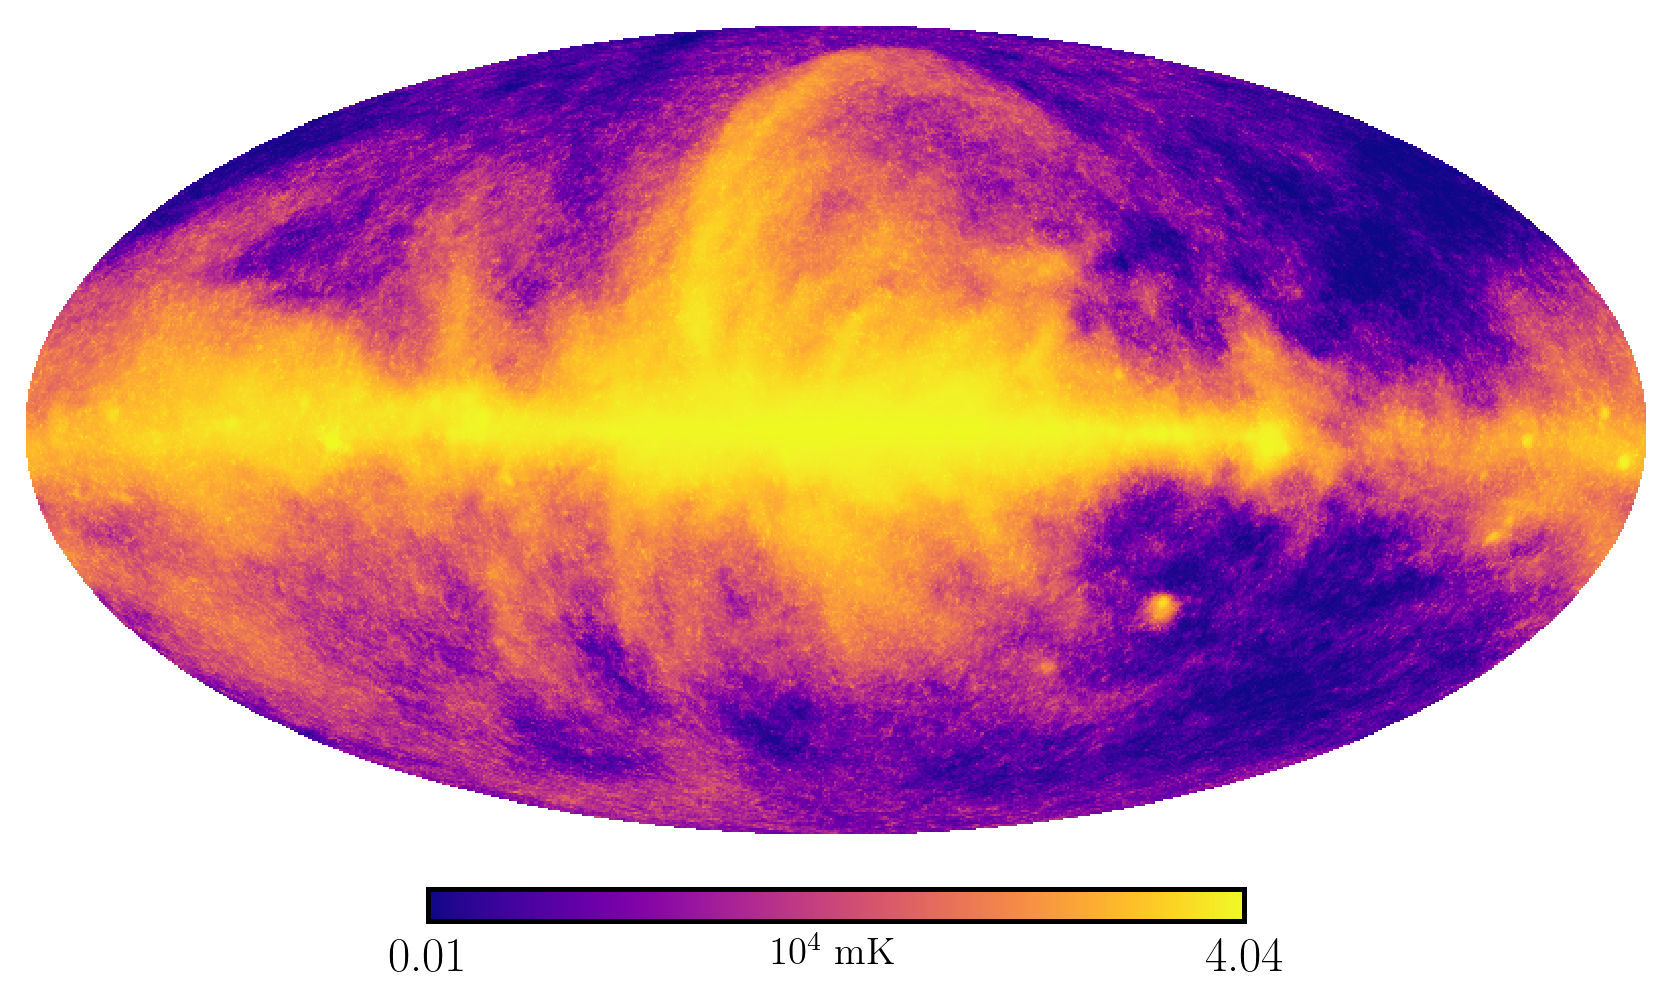

In [3]:
# Synchrotron emission map (dominant foreground at low frequencies)
hp.mollview(sync_map[0]/1e4, cmap="plasma", norm="hist", unit=r"$10^4$ mK", format="%.2f", title=None)
plt.savefig("plots/sync.pdf", bbox_inches="tight")
plt.savefig("plots/sync.png", dpi=500, bbox_inches="tight")

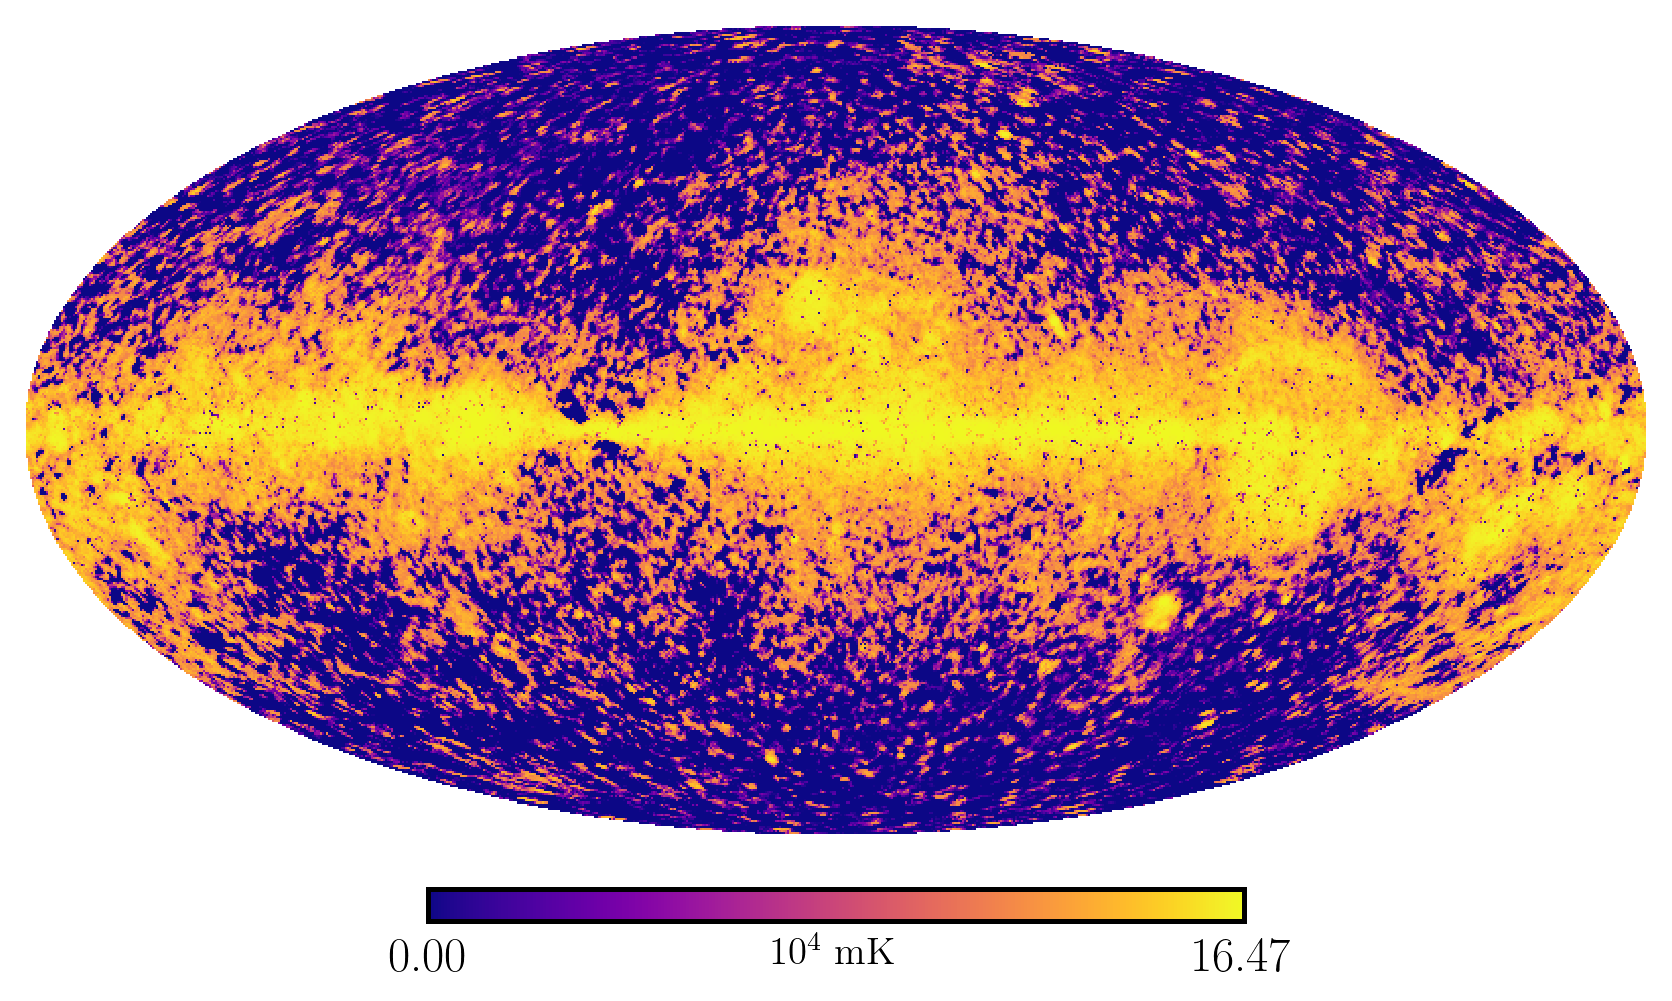

In [4]:
# Free-free emission map (thermal emission from ionized gas)
hp.mollview(freefree_map[0]/1e4, cmap="plasma", norm="hist", unit=r"$10^4$ mK", format="%.2f", title=None)
plt.savefig("plots/free_free.pdf", bbox_inches="tight")
plt.savefig("plots/free_free.png", dpi=500, bbox_inches="tight")

In [5]:
np.min(freefree_map[0]), np.max(freefree_map[0])

(<Quantity 0.00011298 mK_CMB>, <Quantity 164696.55250389 mK_CMB>)

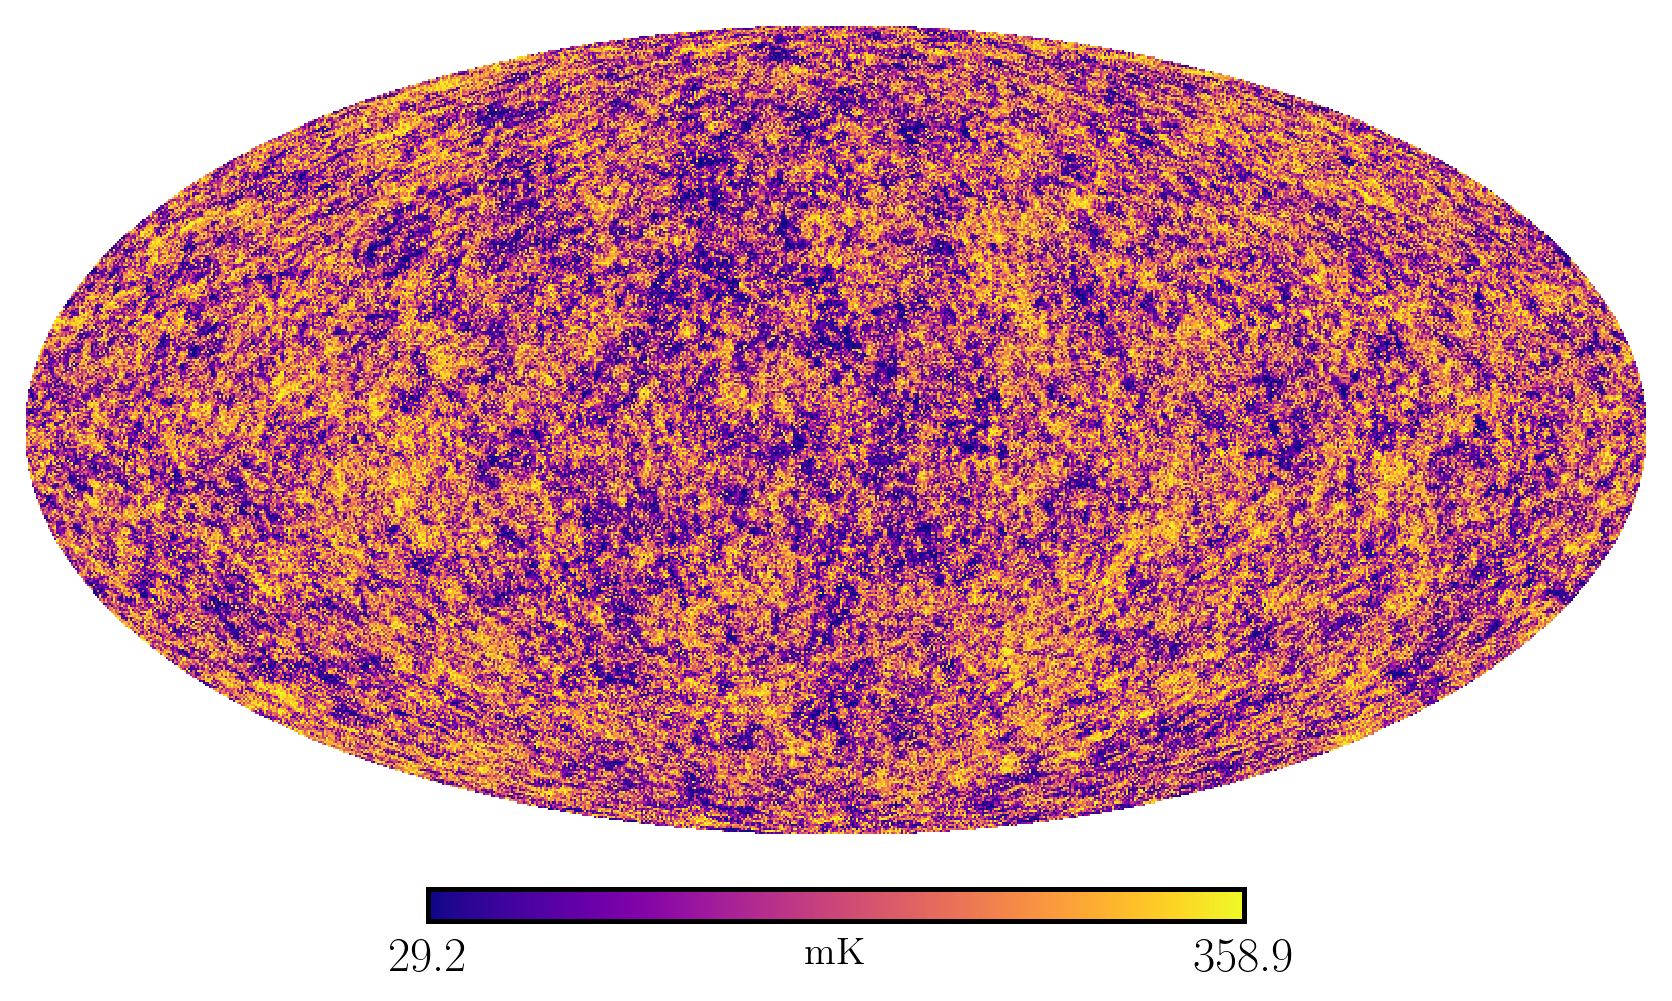

In [6]:
# Point source map (discrete radio sources)
hp.mollview(pt_srcs, cmap="plasma", norm="hist", unit=r"mK", format="%.1f", title=None)
plt.savefig("plots/pt_srcs.pdf", bbox_inches="tight")
plt.savefig("plots/pt_srcs.png", dpi=500, bbox_inches="tight")

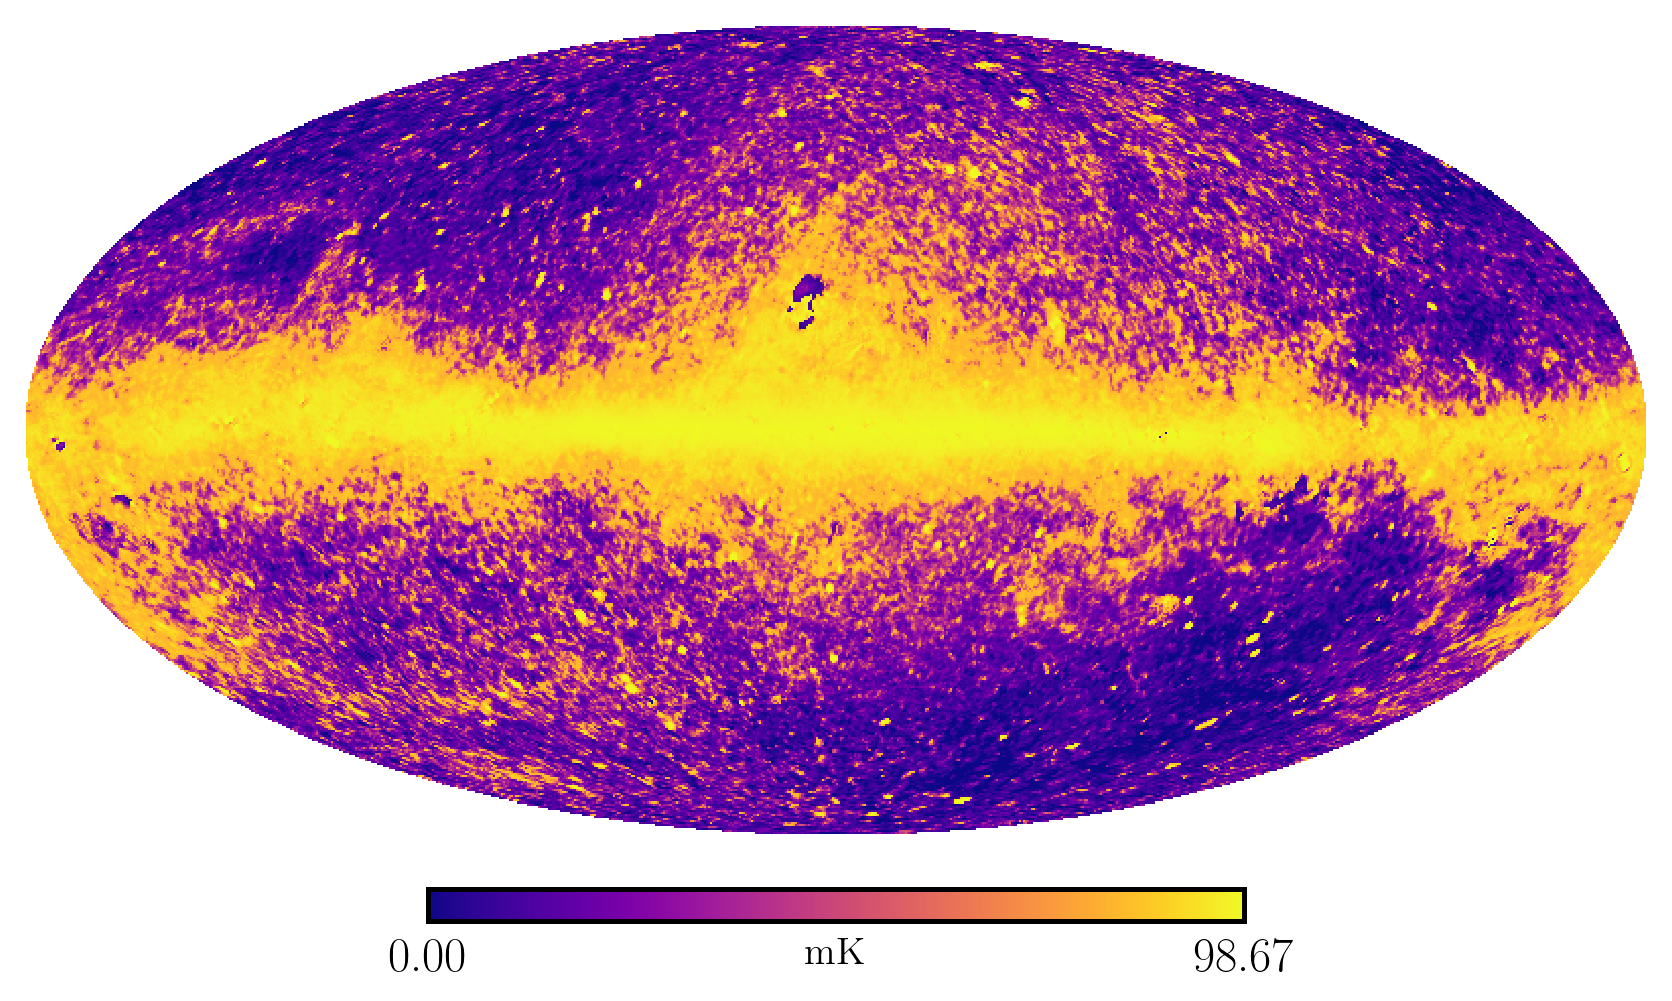

In [7]:
# AME emission map (dominant foreground at low frequencies)
hp.mollview(ame_maps[0], cmap="plasma", norm="hist", unit=r"mK", format="%.2f", title=None)
plt.savefig("plots/ame.pdf", bbox_inches="tight")
plt.savefig("plots/ame.png", dpi=500, bbox_inches="tight")